In [ ]:
# =========================
# Install libraries
# =========================
!pip install xgboost lightgbm -q

In [ ]:
# =========================
# Imports
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
# =========================
# 1. Load IoT-23 Zeek file
# =========================

file_path = "/content/netsec.csv"

with open(file_path, "r") as f:
    for line in f:
        if line.startswith("#fields"):
            columns = line.strip().split("\t")[1:]
            break

df = pd.read_csv(
    file_path,
    sep="\t",
    comment="#",
    names=columns,
    low_memory=False
)

df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)
print(df.head())

Original dataset shape: (23145, 23)
             ts                 uid      id.orig_h  id.orig_p       id.resp_h  \
0  1.545404e+09   CrDn63WjJEmrWGjqf  192.168.1.195      41040  185.244.25.235   
1  1.545404e+09  CY9lJW3gh1Eje4usP6  192.168.1.195      41040  185.244.25.235   
2  1.545404e+09   CcFXLynukEDnUlvgl  192.168.1.195      41040  185.244.25.235   
3  1.545404e+09   CDrkrSobGYxHhYfth  192.168.1.195      41040  185.244.25.235   
4  1.545404e+09  CTWZQf2oJSvq6zmPAc  192.168.1.195      41042  185.244.25.235   

   id.resp_p proto service  duration orig_bytes  ... local_resp missed_bytes  \
0         80   tcp       -  3.139211          0  ...          -            0   
1         80   tcp       -         -          -  ...          -            0   
2         80   tcp       -         -          -  ...          -            0   
3         80   tcp    http  1.477656        149  ...          -         2896   
4         80   tcp       -  3.147116          0  ...          -            0 

In [ ]:
# =========================
# 2. Data cleaning
# =========================

df = df.replace(["-", "?", "nan", "NaN", "inf", "-inf", "Infinity"], np.nan)

features = [
    "duration",
    "orig_pkts",
    "orig_ip_bytes",
    "conn_state",
    "orig_bytes",
]

features = [f for f in features if f in df.columns]

df_model = df[features + ["label"]].copy()

# Categorical feature
if "conn_state" in df_model.columns:
    df_model["conn_state"] = df_model["conn_state"].astype("category").cat.codes

# Label: Benign = 0, Attack = 1
df_model["label"] = df_model["label"].apply(
    lambda x: 0 if str(x).strip().lower() == "benign" else 1
)

# Convert features to numeric
for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Remove infinity and fill missing values
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model[features] = df_model[features].fillna(df_model[features].median())
df_model[features] = df_model[features].fillna(0)

print("Cleaned dataset shape:", df_model.shape)
print("Label distribution:")
print(df_model["label"].value_counts())

print("NaN count:", df_model[features].isna().sum().sum())

Cleaned dataset shape: (23145, 6)
Label distribution:
label
1    21222
0     1923
Name: count, dtype: int64
NaN count: 0


/tmp/ipykernel_5474/3426739641.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["-", "?", "nan", "NaN", "inf", "-inf", "Infinity"], np.nan)


In [ ]:
# =========================
# 3. Split X and y
# =========================

X = df_model[features]
y = df_model["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# =========================
# 4. Scale features
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Benign-only training data for unsupervised models
X_train_normal = X_train_scaled[y_train == 0]

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_normal:", X_train_normal.shape)

print("NaN in train:", np.isnan(X_train_scaled).sum())
print("NaN in test:", np.isnan(X_test_scaled).sum())

X_train_scaled: (18516, 5)
X_test_scaled: (4629, 5)
X_train_normal: (1538, 5)
NaN in train: 0
NaN in test: 0


In [ ]:
# =========================
# Supervised ML models
# =========================

supervised_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# =========================
# Evaluate supervised models
# =========================

supervised_results = []
trained_supervised_models = {}

for name, model in supervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    latency = pred_time / len(X_test_scaled)

    try:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except:
        auc = np.nan

    supervised_results.append({
        "Model": name,
        "Type": "Supervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_supervised_models[name] = model

supervised_results_df = pd.DataFrame(supervised_results)
supervised_results_df


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training SVM...

Training KNN...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 16978, number of negative: 1538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 18516, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.916937 -> initscore=2.401436
[LightGBM] [Info] Start training from score 2.401436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Logistic Regression,Supervised,0.954418,0.952637,1.000000,0.975744,0.851353,0.034282,0.000534,1.153721e-07
1,Decision Tree,Supervised,0.995679,0.996707,0.998586,0.997646,0.994080,0.017300,0.000829,1.791873e-07
2,Random Forest,Supervised,0.996111,0.996943,0.998822,0.997881,0.997472,0.856573,0.046374,1.001822e-05
3,SVM,Supervised,0.955066,0.953279,1.000000,0.976081,0.994220,32.380256,0.528259,1.141195e-04
4,KNN,Supervised,0.996328,0.996010,1.000000,0.998001,0.984363,0.014187,0.563549,1.217431e-04
5,XGBoost,Supervised,0.996328,0.996476,0.999529,0.998000,0.998370,0.180227,0.010138,2.190113e-06
6,LightGBM,Supervised,0.995679,0.996474,0.998822,0.997647,0.998113,0.202767,0.017906,3.868314e-06


In [ ]:
# =========================
# Unsupervised anomaly models
# =========================

unsupervised_models = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42
    ),

    "One-Class SVM": OneClassSVM(
        kernel="rbf",
        nu=0.1,
        gamma="scale"
    ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.1,
        novelty=True
    )
}

In [ ]:
# =========================
# Evaluate unsupervised models
# =========================

unsupervised_results = []
trained_unsupervised_models = {}

for name, model in unsupervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_normal)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    # sklearn anomaly output:
    # 1 = normal, -1 = anomaly
    y_pred = np.where(pred == -1, 1, 0)

    latency = pred_time / len(X_test_scaled)

    try:
        scores = -model.decision_function(X_test_scaled)
        auc = roc_auc_score(y_test, scores)
    except:
        auc = np.nan

    unsupervised_results.append({
        "Model": name,
        "Type": "Unsupervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_unsupervised_models[name] = model

unsupervised_results_df = pd.DataFrame(unsupervised_results)
unsupervised_results_df


Training Isolation Forest...

Training One-Class SVM...

Training Local Outlier Factor...


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Isolation Forest,Unsupervised,0.891769,0.991594,0.889491,0.937772,0.934815,0.211271,0.051986,0.000011
1,One-Class SVM,Unsupervised,0.671203,0.949175,0.677663,0.790762,0.747593,0.026584,0.033447,0.000007
2,Local Outlier Factor,Unsupervised,0.880968,0.989918,0.879123,0.931237,0.915562,0.023005,0.040411,0.000009


In [ ]:
# =========================
# Final model comparison table
# =========================

final_results = pd.concat(
    [supervised_results_df, unsupervised_results_df],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="F1-score",
    ascending=False
)

final_results

,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
4,KNN,Supervised,0.996328,0.996010,1.000000,0.998001,0.984363,0.014187,0.563549,1.217431e-04
5,XGBoost,Supervised,0.996328,0.996476,0.999529,0.998000,0.998370,0.180227,0.010138,2.190113e-06
2,Random Forest,Supervised,0.996111,0.996943,0.998822,0.997881,0.997472,0.856573,0.046374,1.001822e-05
6,LightGBM,Supervised,0.995679,0.996474,0.998822,0.997647,0.998113,0.202767,0.017906,3.868314e-06
1,Decision Tree,Supervised,0.995679,0.996707,0.998586,0.997646,0.994080,0.017300,0.000829,1.791873e-07
3,SVM,Supervised,0.955066,0.953279,1.000000,0.976081,0.994220,32.380256,0.528259,1.141195e-04
0,Logistic Regression,Supervised,0.954418,0.952637,1.000000,0.975744,0.851353,0.034282,0.000534,1.153721e-07
7,Isolation Forest,Unsupervised,0.891769,0.991594,0.889491,0.937772,0.934815,0.211271,0.051986,1.123050e-05
9,Local Outlier Factor,Unsupervised,0.880968,0.989918,0.879123,0.931237,0.915562,0.023005,0.040411,8.729859e-06
8,One-Class SVM,Unsupervised,0.671203,0.949175,0.677663,0.790762,0.747593,0.026584,0.033447,7.225489e-06


In [ ]:
# =========================
# Save model comparison results
# =========================

final_results.to_csv("model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

Saved: model_comparison_results.csv


In [ ]:
# =========================
# Confusion matrices and reports
# =========================

for name, model in trained_supervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    y_pred = model.predict(X_test_scaled)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
Confusion Matrix:
[[ 174  211]
 [   0 4244]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.45      0.62       385
           1       0.95      1.00      0.98      4244

    accuracy                           0.95      4629
   macro avg       0.98      0.73      0.80      4629
weighted avg       0.96      0.95      0.95      4629


Decision Tree
Confusion Matrix:
[[ 371   14]
 [   6 4238]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       385
           1       1.00      1.00      1.00      4244

    accuracy                           1.00      4629
   macro avg       0.99      0.98      0.99      4629
weighted avg       1.00      1.00      1.00      4629


Random Forest
Confusion Matrix:
[[ 372   13]
 [   5 4239]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
for name, model in trained_unsupervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    pred = model.predict(X_test_scaled)
    y_pred = np.where(pred == -1, 1, 0)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Isolation Forest
Confusion Matrix:
[[ 353   32]
 [ 469 3775]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.92      0.58       385
           1       0.99      0.89      0.94      4244

    accuracy                           0.89      4629
   macro avg       0.71      0.90      0.76      4629
weighted avg       0.94      0.89      0.91      4629


One-Class SVM
Confusion Matrix:
[[ 231  154]
 [1368 2876]]

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.60      0.23       385
           1       0.95      0.68      0.79      4244

    accuracy                           0.67      4629
   macro avg       0.55      0.64      0.51      4629
weighted avg       0.88      0.67      0.74      4629


Local Outlier Factor
Confusion Matrix:
[[ 347   38]
 [ 513 3731]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      

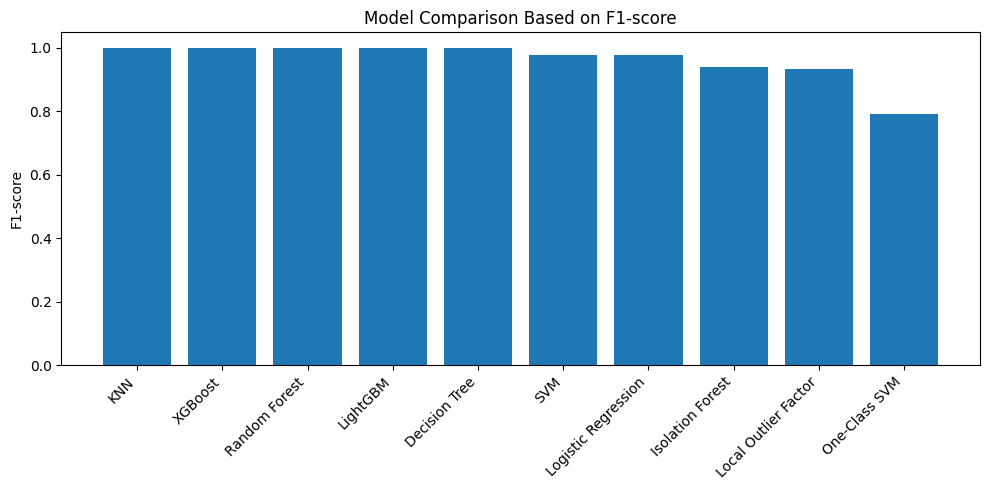

In [ ]:
# =========================
# Bar chart: model comparison
# =========================

plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")
plt.tight_layout()
plt.show()

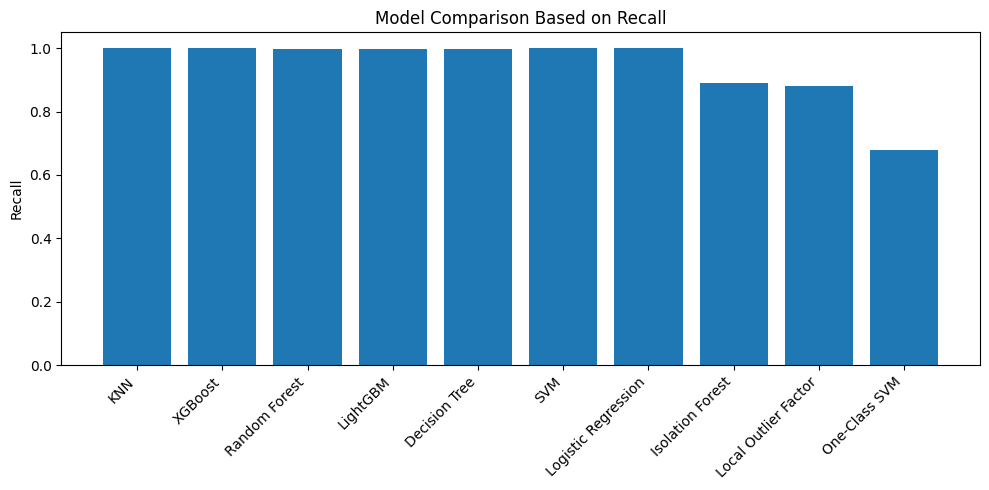

In [ ]:
# =========================
# Plot Recall comparison
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Recall"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Recall")

plt.title("Model Comparison Based on Recall")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

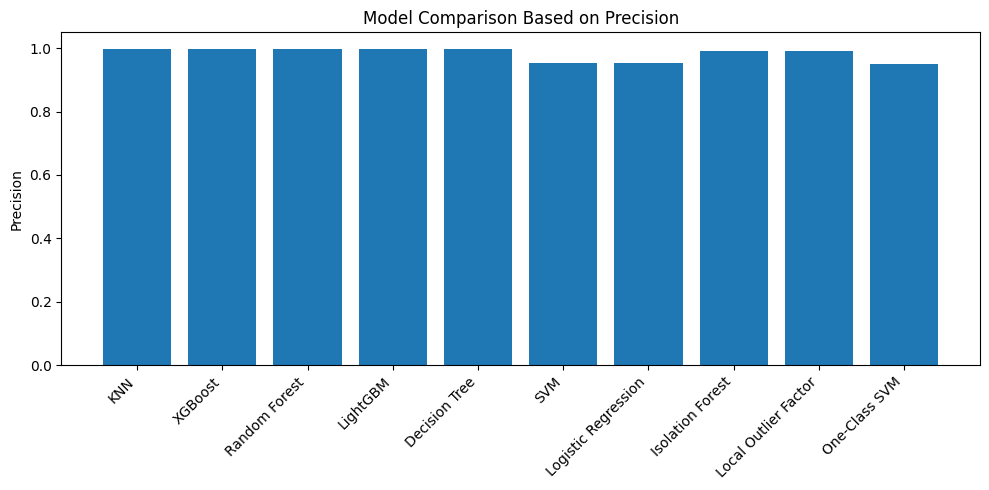

In [ ]:
# =========================
# Plot Precision comparison
# =========================

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Precision"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Precision")

plt.title("Model Comparison Based on Precision")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

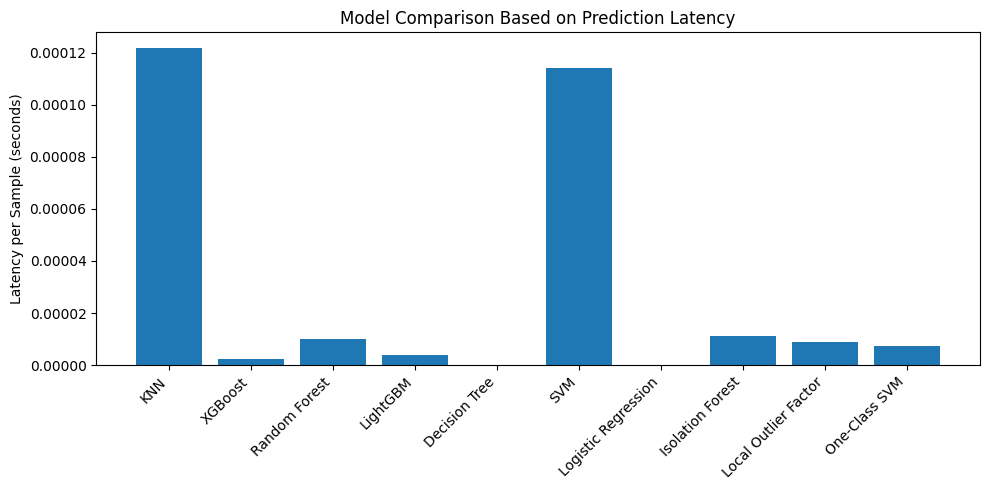

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["Latency per Sample (s)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Latency per Sample (seconds)")
plt.title("Model Comparison Based on Prediction Latency")
plt.tight_layout()
plt.show()

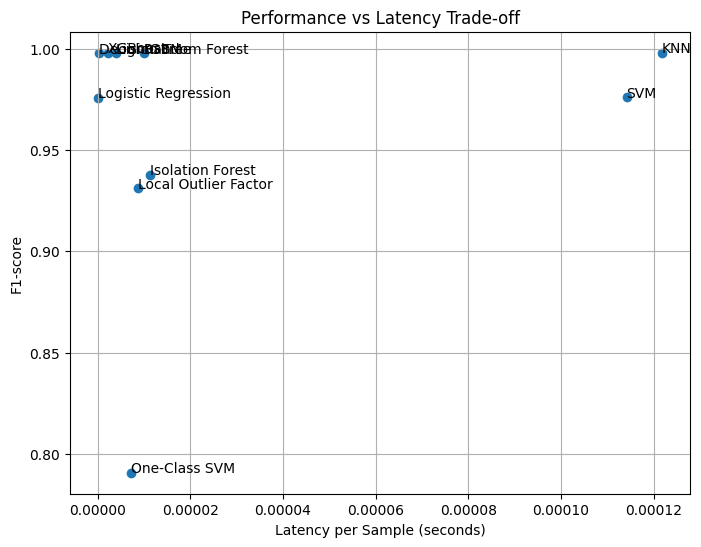

In [ ]:
# =========================
# F1-score vs Latency
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["F1-score"]
)

for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["F1-score"],
        row["Model"]
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("F1-score")

plt.title("Performance vs Latency Trade-off")

plt.grid(True)

plt.show()

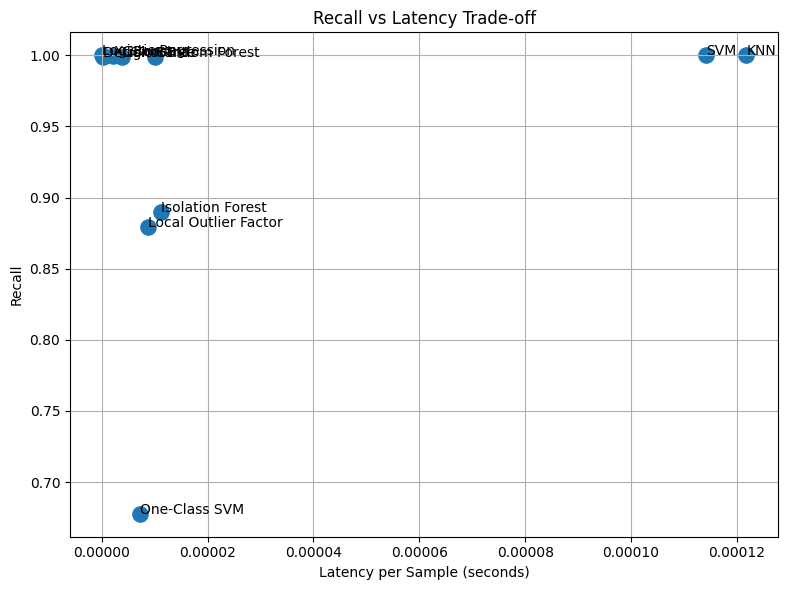

In [ ]:
# =========================
# Recall vs Latency Trade-off
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["Recall"],
    s=120
)

# Add model labels
for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["Recall"],
        row["Model"],
        fontsize=10
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("Recall")

plt.title("Recall vs Latency Trade-off")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# =========================
# Feature importance function
# =========================

def get_feature_importance(model, model_name, features):
    importance = model.feature_importances_

    fi_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(f"\n{model_name} Feature Importance")
    display(fi_df)

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df["Feature"], fi_df["Importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} Feature Importance")
    plt.tight_layout()
    plt.show()

    return fi_df


Random Forest Feature Importance


,Feature,Importance
2,orig_ip_bytes,0.364051
3,conn_state,0.211683
1,orig_pkts,0.204076
0,duration,0.172623
4,orig_bytes,0.047568


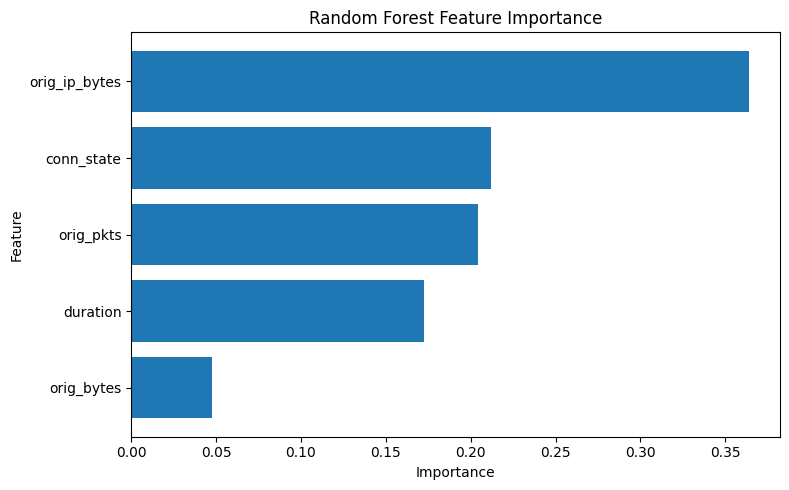


XGBoost Feature Importance


,Feature,Importance
1,orig_pkts,0.340890
3,conn_state,0.298312
2,orig_ip_bytes,0.292600
4,orig_bytes,0.066390
0,duration,0.001808


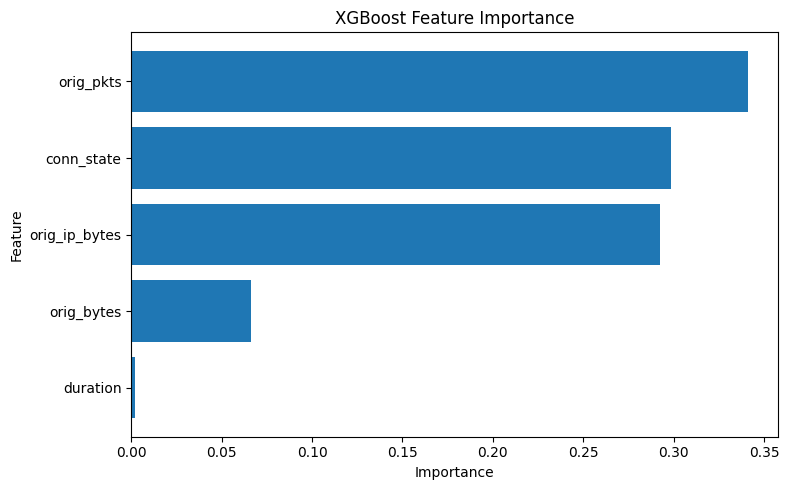


LightGBM Feature Importance


,Feature,Importance
0,duration,1959
1,orig_pkts,524
2,orig_ip_bytes,285
3,conn_state,182
4,orig_bytes,47


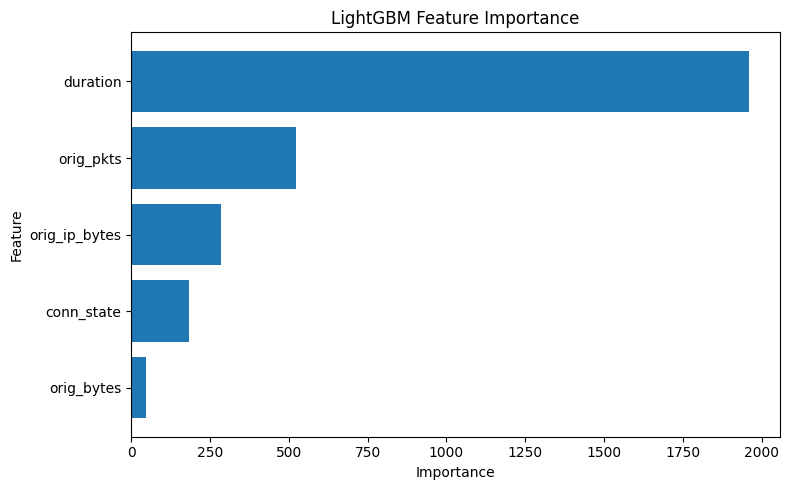

In [ ]:
# =========================
# Feature importance from tree-based models
# =========================

rf_importance = get_feature_importance(
    trained_supervised_models["Random Forest"],
    "Random Forest",
    features
)

xgb_importance = get_feature_importance(
    trained_supervised_models["XGBoost"],
    "XGBoost",
    features
)

lgbm_importance = get_feature_importance(
    trained_supervised_models["LightGBM"],
    "LightGBM",
    features
)

In [ ]:
# =========================
# Combined average feature importance
# =========================

combined_importance = pd.DataFrame({
    "Feature": features
})

combined_importance = combined_importance.merge(
    rf_importance.rename(columns={"Importance": "Random Forest"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    xgb_importance.rename(columns={"Importance": "XGBoost"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    lgbm_importance.rename(columns={"Importance": "LightGBM"}),
    on="Feature"
)

combined_importance["Average Importance"] = combined_importance[
    ["Random Forest", "XGBoost", "LightGBM"]
].mean(axis=1)

combined_importance = combined_importance.sort_values(
    by="Average Importance",
    ascending=False
)

combined_importance

,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,duration,0.172623,0.001808,1959,653.058144
1,orig_pkts,0.204076,0.340890,524,174.848322
2,orig_ip_bytes,0.364051,0.292600,285,95.218884
3,conn_state,0.211683,0.298312,182,60.836665
4,orig_bytes,0.047568,0.066390,47,15.704653


In [ ]:
# =========================
# Save feature importance
# =========================

combined_importance.to_csv("feature_importance_results.csv", index=False)
print("Saved: feature_importance_results.csv")

Saved: feature_importance_results.csv


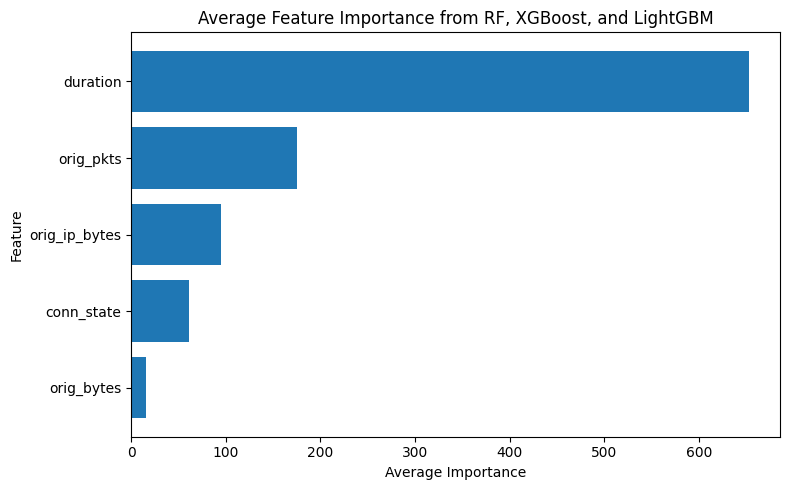

In [ ]:
# =========================
# Plot average feature importance
# =========================

plt.figure(figsize=(8, 5))
plt.barh(
    combined_importance["Feature"],
    combined_importance["Average Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.title("Average Feature Importance from RF, XGBoost, and LightGBM")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Print final best model and best features
# =========================

best_model = final_results.iloc[0]

print("Best Model:")
print(best_model)

print("\nTop 10 Important Features:")
display(combined_importance.head(10))

Best Model:
Model                            KNN
Type                      Supervised
Accuracy                    0.996328
Precision                    0.99601
Recall                           1.0
F1-score                    0.998001
AUC                         0.984363
Training Time (s)           0.014187
Prediction Time (s)         0.563549
Latency per Sample (s)      0.000122
Name: 4, dtype: object

Top 10 Important Features:


,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,duration,0.172623,0.001808,1959,653.058144
1,orig_pkts,0.204076,0.340890,524,174.848322
2,orig_ip_bytes,0.364051,0.292600,285,95.218884
3,conn_state,0.211683,0.298312,182,60.836665
4,orig_bytes,0.047568,0.066390,47,15.704653
